# Playground — poke at each step by hand

**This notebook is yours to edit.** Every cell has a knob; change it and re-run.
(The read-only companion, `01_reasoning_log.ipynb`, is generated from
`tools/build_notebook.py` — edits there get overwritten. This one is generated
once by `tools/build_playground.py`, so copy it aside before re-running that.)

Everything runs in a second or two at these sizes. The question each step
answers:

| step | question |
|---|---|
| 1 | what does my mask look like, and is it well-formed? |
| 2 | how much work does a block mask waste on it? |
| 3 | does a change of basis help — and what does it cost? |
| 4 | which of the legal transforms is best? |
| 5 | would splitting the mask into parts do better? |
| 6 | how do I sweep a parameter and plot it? |

Background for any of it: [`docs/NOTES.md`](../docs/NOTES.md).

In [1]:
%matplotlib inline
from polyattn.explore import *

sorted(ZOO)      # the built-in masks you can refer to by name

['causal',
 'dilated-2',
 'dilated-4',
 'dilated-8',
 'docpack-2048',
 'docpack-512',
 'local256+str8',
 'prefixlm-1024',
 'sinks4+win1024',
 'sinks4+win256',
 'window-1024',
 'window-128',
 'window-256',
 'window-4096',
 'window-512']

## Step 1 — pick a mask, or write one

Two ways in. Either name one from `ZOO`, or write a predicate.

`Custom` takes `fn(q, kv) -> bool` evaluated on a meshgrid, so use numpy
operators — `&`, `|`, `~` — not Python's `and`/`or`. It derives everything
densely, which is exact but $O(N^2)$: keep `N` at a few thousand.

**Try changing the predicate below.** A few to start from:

```python
Custom(lambda q, kv: kv <= q,                              "causal")
Custom(lambda q, kv: (kv <= q) & (q - kv < 100),           "window-100")
Custom(lambda q, kv: (kv <= q) & ((q - kv) % 8 == 0),      "every-8th")
Custom(lambda q, kv: (kv <= q) & ((q - kv < 64) | (kv < 4)), "sinks + window")
Custom(lambda q, kv: (kv <= q) & ((q // 128) == (kv // 128)), "block-diagonal")
```

In [2]:
m = Custom(lambda q, kv: (kv <= q) & (q - kv < 100), "my-window")

validate(m)      # brute-force check -- always run this on a mask you wrote

my-window: OK


True

Draw it. Blue is live; **pink is computed but dead** — that is the waste a block
mask pays. `block=` is the tile size, `N=` the sequence length shown.

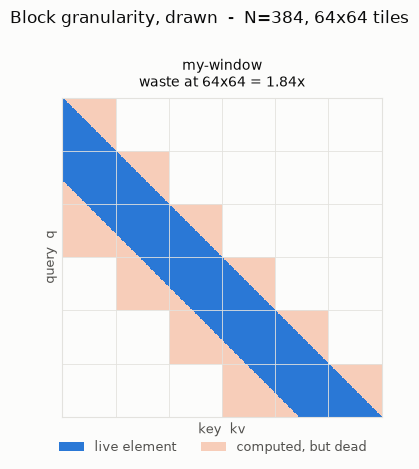

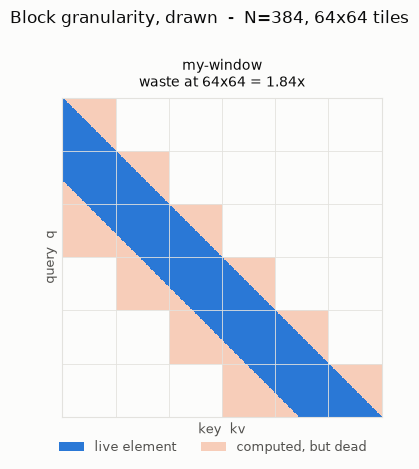

In [3]:
show(m, N=384, block=64)

## Step 2 — what does block granularity cost?

`waste_table` reports *elements computed / live elements* at each tile size.
`1.00` is perfect; `2.00` means half the work is thrown away.

The row that matters most is **128×128** — that is what FlexAttention's
`BlockMask` does today — against **16×16**, the floor tensor cores impose
(MMA is `m16n8k16`-shaped, so nothing finer is skippable in hardware).

In [4]:
_ = waste_table(m, N=2048)

my-window  N=2048  live=199,850  density=4.76%

    BQ x A        computed    waste
-----------------------------------
   128x128         507,904    2.541
     64x64         380,928    1.906
     32x32         317,440    1.588
     16x16         254,976    1.276


**Worth trying:** shrink the window in step 1 to 32 and re-run. The 128×128 waste
climbs sharply while 16×16 barely moves — narrow bands are where finer bounds pay.
Then set the window to 2048 and watch the whole table collapse to 1.00: there is
nothing to win on a mask that is already dense.

## Step 3 — try a change of basis

A transform re-indexes the iteration space. Only two families are legal, because
attention reduces over `kv` at fixed `q`:

| | transform | class | cost |
|---|---|---|---|
| keys | $kv' = \pi(kv)$ | **A** | free — permute K/V once per layer |
| keys | $kv' = (kv - aq)/s$ | **B** | per-tile gather, **cannot be amortised** |

`try_transform` reports *both* axes — FLOPs saved and traffic added — and calls
out the case where traffic grows faster than work shrinks.

Available: `identity`, `shear`, `residue-perm-{2,4,8}`, `stridefold-{2,4,8}`.

every-8th  --residue-perm-8-->   class A  (free: permute K/V once per layer)
  waste at 16x16   8.062  ->  1.116   (7.22x fewer elements)
  kv rows / tile      16  ->  16   (1.00x traffic)


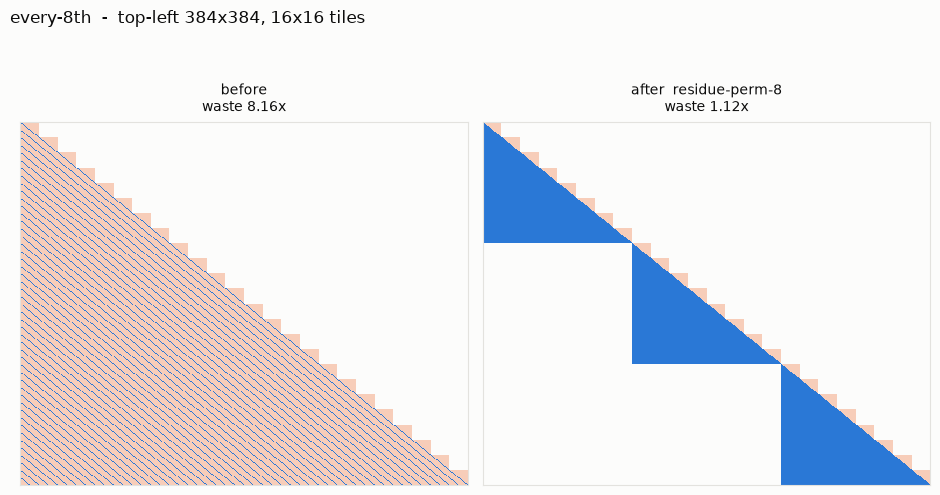

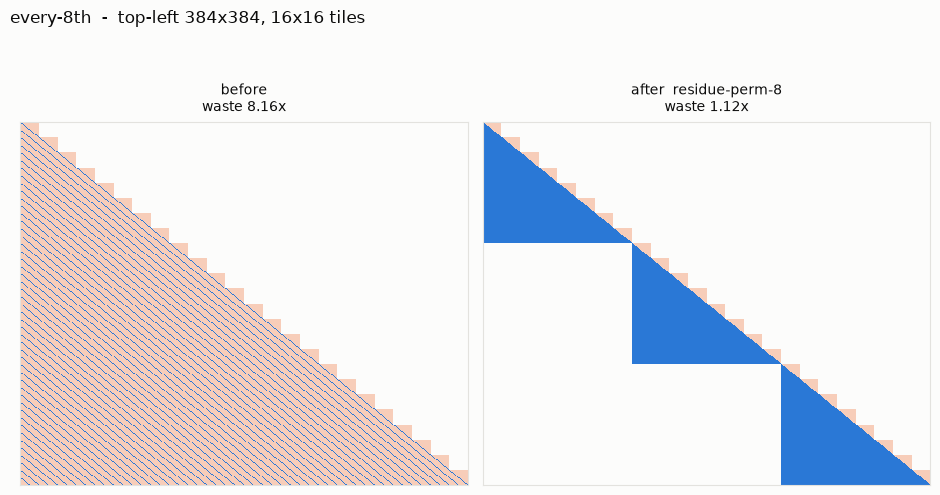

In [5]:
strided = Custom(lambda q, kv: (kv <= q) & ((q - kv) % 8 == 0), "every-8th")

try_transform(strided, "residue-perm-8", N=1024)

That is the headline result: an 8× waste collapses to ~1.1 at **no traffic cost**,
because the permutation is independent of `q` and so can be applied to K/V once.

Now the counter-example. `shear` straightens a diagonal band into a rectangle and
drives waste to 1.00 — but it is class B, so every tile needs a different slice
of K/V:

window-128  --shear-->   class B  (per-tile gather, NOT amortisable)
  waste at 16x16   1.124  ->  1.008   (1.12x fewer elements)
  kv rows / tile      16  ->  31   (1.94x traffic)
  VERDICT: net loss -- traffic grows faster than work shrinks.


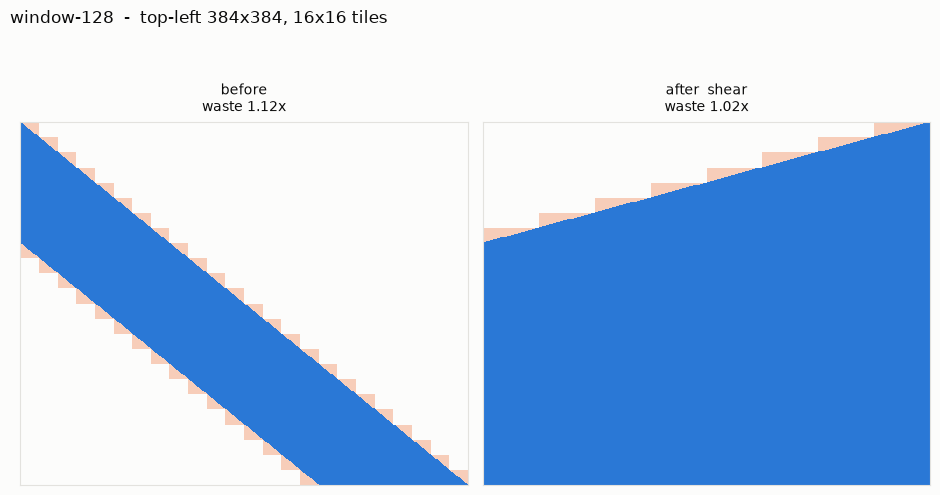

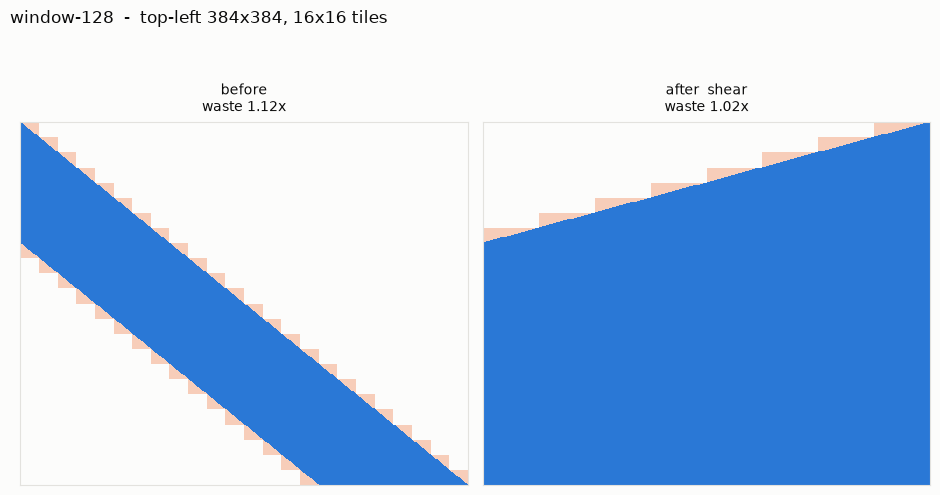

In [6]:
try_transform("window-128", "shear", N=1024)

**Worth trying:** `try_transform(strided, "stridefold-8")`. It reaches exactly the
same waste as `residue-perm-8` and is useless anyway — same work, ~8× the traffic.
That pair is the clearest illustration of why the class matters more than the
element count.

## Step 4 — search all the legal transforms

In [7]:
_ = best_transform(strided, N=1024)

every-8th  N=1024  grain 16x16

transform          cls    waste  kv/tile  free?
-----------------------------------------------
residue-perm-8       A    1.116       16    yes
stridefold-8         B    1.116      136     no
residue-perm-4       A    2.109       16    yes
stridefold-4         B    2.109       76     no
residue-perm-2       A    4.093       16    yes
stridefold-2         B    4.093       46     no
identity             A    8.062       16    yes
shear                B    8.062       31     no


Read the `cls` and `kv/tile` columns together. Rows with identical `waste` are not
equivalent: `residue-perm-8` and `stridefold-8` compute the same amount, but one
reads 16 kv rows per tile and the other 136.

**Worth trying:** run this on `"docpack-512"` (unaligned document boundaries) and
on `"causal"`. Neither has a transform that helps — for different reasons.

## Step 5 — split the mask into parts

If a mask is a *union* of differently-structured families, no single basis suits
all of it. Split it into **disjoint** parts, give each its own basis, and merge
with the online-softmax (log-sum-exp) combine — the same trick flash-decoding
uses to split the kv axis.

Disjointness is not cosmetic: an element counted twice would be double-counted in
the softmax denominator.

In [8]:
_ = split("local256+str8", N=512, kmax=2, top=6)

local256+str8  N=512  live=102,656  grain 16x16

  waste 1.077   k=2   band-256[identity] + lattice-8[residue-perm-8]
  waste 1.077   k=2   band-256[identity] + lattice-2[residue-perm-8]
  waste 1.077   k=2   band-256[identity] + lattice-4[residue-perm-8]
  waste 1.077   k=2   band-256[identity] + all[residue-perm-8]
  waste 1.197   k=2   lattice-2[residue-perm-4] + all[residue-perm-2]
  waste 1.217   k=1   band-512[residue-perm-2]


The winner splits a mask that resisted every single transform (1.24) into a band
in the identity basis plus a lattice under `residue-perm-8`, reaching ~1.05.

**Worth trying:** `split("sinks4+win256")`. Splitting makes it *worse* — a 4-wide
sink prefix still occupies a full 16-wide tile, so peeling it off costs more than
it saves. A sub-mask narrower than the MMA granularity should never be split out.

## Step 6 — your own experiment

A template: sweep one parameter, plot the three granularities. Change the family,
the range, or the granularities and re-run.

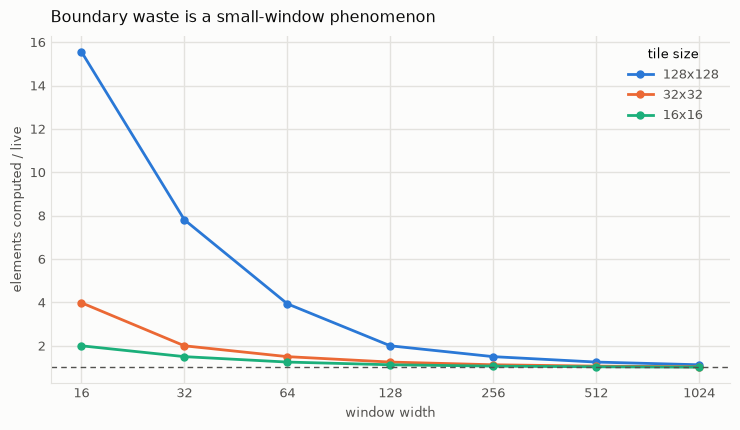

In [9]:
import matplotlib.pyplot as plt
from polyattn import figures as F

N = 2048
widths = [16, 32, 64, 128, 256, 512, 1024]
grains = [(128, 128), (32, 32), (16, 16)]

series = {g: [] for g in grains}
for w in widths:
    mk = Custom(lambda q, kv, w=w: (kv <= q) & (q - kv < w), f"w{w}")
    live = mk.live_count(N)
    for g in grains:
        series[g].append(cost.cost(mk, N, *g, exact_only=True)[0] / live)

fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor=F.SURF)
ax.set_facecolor(F.SURF)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
for sp in ("left", "bottom"):
    ax.spines[sp].set_color(F.GRID)
ax.grid(True, color=F.GRID, lw=1); ax.set_axisbelow(True)
ax.tick_params(colors=F.INK2, labelsize=9, length=0)

for (g, ys), col in zip(series.items(), (F.S1, F.S2, F.S3)):
    ax.plot(widths, ys, marker="o", ms=5, lw=2, color=col, label=f"{g[0]}x{g[1]}")
ax.axhline(1.0, color=F.INK2, lw=1, ls=(0, (4, 3)))
ax.set_xscale("log", base=2); ax.set_xticks(widths)
ax.set_xticklabels(widths); ax.set_xlabel("window width", color=F.INK2, fontsize=9.5)
ax.set_ylabel("elements computed / live", color=F.INK2, fontsize=9.5)
ax.set_title("Boundary waste is a small-window phenomenon", loc="left",
             color=F.INK, fontsize=11.5, pad=10)
ax.legend(frameon=False, fontsize=9, labelcolor=F.INK2, title="tile size",
          title_fontsize=9)
fig.tight_layout()

## Scratch

Yours. `from polyattn.explore import *` already gave you `masks`, `transforms`,
`compose` and `cost` if you want the lower-level API.

Useful entry points:

```python
cost.cost(m, N, BQ, A, exact_only=True)     # (elements computed, was_sampled)
transforms.tile_stats(M, BQ, A)             # (tiles, elements) on a dense array
transforms.candidates()                     # [(name, fn), ...]
compose.search(m, N=512, kmax=2)            # full decomposition search
m.dense(N)                                  # the raw N x N boolean mask
```